### Example - Temperature map in the North West Atlantic

This example shows how to read and manipulate CrocoLake data stored in parquet format. The data are stored across multiple files: we will load into memory only what we need by applying some filters, and we will create a map showing the temperature measurements in the demo data (approximately the North West Atlantic).

CrocoLake contains QCed data from different datasets (Argo, GLODAP, Spray Gliders as of today). This example uses the demo data created with `crocolaketools`; for more examples see the [CrocoLake-Python repository](https://github.com/boom-lab/crocolake-python).

##### Note on parquet files
There are several ways to load parquet files in a dataframe in Python, and this notebook shows two of them:

1. pandas + pyarrow: this approach uses the pyarrow package to load the data into a pandas dataframe;
2. dask (+ pandas + pyarrow): this approach uses the dask package to load the data into a dask dataframe; it uses pandas and pyarrow under the hood, and a dask dataframe is (almost) identical to a pandas dataframe.

We will first use pyarrow to load the dataset, so that we can provide a target schema (containing the Argo variable names) and load the data consistently across floats, independently of what variables each float actually has. We will finally convert the dataset to a pandas dataframe for manipulation and plots.

Other ways to read parquet files are by using pandas (make sure you have pyarrow, fastparquet or some other suitable engine installed), and Dask. Generally speaking, you'll want to use Dask only if you need a large amount of data at the same time so that you can benefit from its parallelization. You should avoid Dask whenever the data fits in your RAM.

When reading parquet files with pyarrow (or pandas), you can either specificy the file name(s), or the directory containing all the parquet files. In latter case if you apply any filter, pandas and pyarrow will sort through all the files in the folder, reading into memory only the subsets that satisfy your filter.

#### Getting started

The script assumes you have run the all the demos and reads the CrocoLake version generated with them.

We then import the necessary modules and set up the path to the dataset (update the `parquet_dir` variable below if you have specified a different location in the previous cell or have moved the dataset).

In [1]:
import datetime
import glob
from pprint import pprint

import pandas as pd
import pyarrow.parquet as pq

# Path to CrocoLake PHY
parquet_dir = '../../crocolaketools/demo/parquet/demo_CROCOLAKE_PHY/'
# Setting up parquet schema
crocolake_schema = pq.read_schema(parquet_dir+"_common_metadata")

### pyarrow + pandas approach

We now create a `ParquetDataset` object that will allow us to read the data. Specifying a schema (that we read into `crocolake_schema` in the previous cell) will make later operations faster.

We can get a peak at what variables are available in the dataset looking at its `schema` attribute. Note that we have not load any data into memory yet (except for the schema).

In [2]:
dataset = pq.ParquetDataset(
    parquet_dir, 
    schema=crocolake_schema
)
schema = dataset.schema
pprint(sorted(schema.names))

['ABS_SAL_COMPUTED',
 'CONSERVATIVE_TEMP_COMPUTED',
 'CYCLE_NUMBER',
 'DATA_MODE',
 'DATE_UPDATE',
 'DB_NAME',
 'DEPTH',
 'JULD',
 'LATITUDE',
 'LONGITUDE',
 'PLATFORM_NUMBER',
 'PRES',
 'PRES_ERROR',
 'PRES_QC',
 'PSAL',
 'PSAL_ERROR',
 'PSAL_QC',
 'SIGMA1_COMPUTED',
 'TEMP',
 'TEMP_ERROR',
 'TEMP_QC']


If we want to filter the dataset to load in memory only the data from a specific region over a specific time frame, we set the ranges for latitude, longitude, and time as below.

The geographical coordinates are stored in the variables 'LATITUDE'and 'LONGITUDE', and time is in 'JULD'. We then generate the filter, with its syntax being: `[[(column, op, val), …],…]` where `column` is the variable name, and `val` is the value to for the operator `op`, which accepts `[==, =, >, >=, <, <=, !=, in, not in]`,

In [3]:
# Geographical boundaries
lat0 = 25
lat1 = 40
lon0 = -55
lon1 = -40

# Time range
date0 = datetime.datetime(2020, 1, 1, 0, 0, 0)
date1 = datetime.datetime(2025, 1, 1, 0, 0, 0)

filter_coords_time = [
    ("LATITUDE",">",lat0), ("LATITUDE","<",lat1),
    ("LONGITUDE",">",lon0), ("LONGITUDE","<",lon1),
    ("JULD",">",date0), ("JULD","<",date1)
]

To get a pandas dataframe, we re-generate a `ParquetDataset` object adding the filters to it, and then we read it into a pandas dataframe with the `read().to_pandas()` methods of the dataset.

In [4]:
%%time
ds = pq.ParquetDataset(parquet_dir, schema=crocolake_schema, filters=filter_coords_time)
df = ds.read().to_pandas()
df

CPU times: user 471 ms, sys: 363 ms, total: 834 ms
Wall time: 128 ms


,DB_NAME,PLATFORM_NUMBER,CYCLE_NUMBER,DATA_MODE,DATE_UPDATE,LATITUDE,LONGITUDE,JULD,PRES,PRES_QC,...,TEMP,TEMP_QC,TEMP_ERROR,PSAL,PSAL_QC,PSAL_ERROR,ABS_SAL_COMPUTED,CONSERVATIVE_TEMP_COMPUTED,SIGMA1_COMPUTED,DEPTH
0,ARGO,4903341,0,D,2025-04-20 16:00:59,26.46885,-52.33352,2021-04-01 07:19:30.000778752,0.96,1,...,23.250999,1,0.002,37.159523,1,0.010011,37.334904,23.171068,29.713116,<NA>
1,ARGO,4903341,0,D,2025-04-20 16:00:59,26.46885,-52.33352,2021-04-01 07:19:30.000778752,1.92,1,...,23.254999,1,0.002,37.152107,1,0.010001,37.327454,23.175129,29.706369,<NA>
2,ARGO,4903341,0,D,2025-04-20 16:00:59,26.46885,-52.33352,2021-04-01 07:19:30.000778752,2.96,1,...,23.266001,1,0.002,37.177372,1,0.01002,37.35284,23.185001,29.722067,<NA>
3,ARGO,4903341,0,D,2025-04-20 16:00:59,26.46885,-52.33352,2021-04-01 07:19:30.000778752,4.0,1,...,23.271,1,0.002,37.187714,1,0.010004,37.363232,23.189409,29.72838,<NA>
4,ARGO,4903341,0,D,2025-04-20 16:00:59,26.46885,-52.33352,2021-04-01 07:19:30.000778752,4.92,1,...,23.277,1,0.002,37.200878,1,0.010001,37.376461,23.194742,29.736502,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426633,GLODAP,325020210316,45,<NA>,2023-10-18 13:01:04,26.472,-52.3337,2021-04-01 03:40:00,4167.700195,<NA>,...,2.2019,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
426634,GLODAP,325020210316,45,<NA>,2023-10-18 13:01:04,26.472,-52.3337,2021-04-01 03:40:00,4476.399902,<NA>,...,2.1498,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
426635,GLODAP,325020210316,45,<NA>,2023-10-18 13:01:04,26.472,-52.3337,2021-04-01 03:40:00,4783.600098,<NA>,...,2.1293,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
426636,GLODAP,325020210316,45,<NA>,2023-10-18 13:01:04,26.472,-52.3337,2021-04-01 03:40:00,4989.299805,<NA>,...,2.1425,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


You can explore the dataframe just by calling it (`df`) as we did above. If you want a list of the variables that are stored, you can use `sorted(df.columns.to_list())`. The following cell shows that we loaded roughly 100 MB of data.

In [5]:
memory_usage = df.memory_usage(deep=True).sum()/(1024**2)
print(f"DataFrame size: {memory_usage:.2f} MB")

DataFrame size: 97.76 MB


If we now that we only need a subset of variables, we can specify them in the dataset's `read()` method. 

For example, let's say that we are interested in the adjusted measurements of the temperature. To exclude non valid and missing observations, we filter the temperature (TEMP) to be within a (large) range of valid values. Besides the temperature, we also want to keep the spatial and time coordinates.

In [6]:
%%time
cols = ["DB_NAME","LATITUDE","LONGITUDE","PRES","JULD","TEMP"]
filter_coords_time_temp = [
    ("LATITUDE",">",lat0), ("LATITUDE","<",lat1),
    ("LONGITUDE",">",lon0), ("LONGITUDE","<",lon1),
    ("JULD",">",date0), ("JULD","<",date1),
    ("TEMP",">=",-1e30),("TEMP","<=",+1e30)
]

ds = pq.ParquetDataset(parquet_dir, schema=crocolake_schema, filters=filter_coords_time_temp)
df = ds.read(columns=cols).to_pandas()

df

CPU times: user 215 ms, sys: 34.2 ms, total: 249 ms
Wall time: 46.9 ms


,DB_NAME,LATITUDE,LONGITUDE,PRES,JULD,TEMP
0,ARGO,26.46885,-52.33352,0.96,2021-04-01 07:19:30.000778752,23.250999
1,ARGO,26.46885,-52.33352,1.92,2021-04-01 07:19:30.000778752,23.254999
2,ARGO,26.46885,-52.33352,2.96,2021-04-01 07:19:30.000778752,23.266001
3,ARGO,26.46885,-52.33352,4.0,2021-04-01 07:19:30.000778752,23.271
4,ARGO,26.46885,-52.33352,4.92,2021-04-01 07:19:30.000778752,23.277
...,...,...,...,...,...,...
422301,GLODAP,26.472,-52.3337,4167.700195,2021-04-01 03:40:00,2.2019
422302,GLODAP,26.472,-52.3337,4476.399902,2021-04-01 03:40:00,2.1498
422303,GLODAP,26.472,-52.3337,4783.600098,2021-04-01 03:40:00,2.1293
422304,GLODAP,26.472,-52.3337,4989.299805,2021-04-01 03:40:00,2.1425


This operation loaded a smaller dataframe (\~35 MB) and is significantly faster (\~3x), which is appreciated when loading larger amounts data. For example, if we are handling the full CrocoLake dataset, now we could take advantage of the filtering to load data from a wider temporal range, as we would not be loading *all* the data, but only the temperature and spatial and temporal coordinates.

In [7]:
memory_usage = df.memory_usage(deep=True).sum()/(1024**2)
print(f"DataFrame size: {memory_usage:.2f} MB")

DataFrame size: 34.49 MB


#### Map

We now produce a temperature map of the demo data. As this is already a small subset of CrocoLake for illustrative purposes, we filter the dataset only by variable names, and to ensure that temperature has finite values.

In [8]:
cols = ["DB_NAME","LATITUDE","LONGITUDE","PRES","JULD","TEMP"]
filter_temp = [
    ("TEMP",">=",-1e30),("TEMP","<=",+1e30)
]

ds = pq.ParquetDataset(parquet_dir, schema=crocolake_schema, filters=filter_temp)
df = ds.read(columns=cols).to_pandas()

memory_usage = df.memory_usage(deep=True).sum()/(1024**2)
print(f"DataFrame size: {memory_usage:.2f} MB")
df

DataFrame size: 364.41 MB


,DB_NAME,LATITUDE,LONGITUDE,PRES,JULD,TEMP
0,ARGO,26.46885,-52.33352,0.96,2021-04-01 07:19:30.000778752,23.250999
1,ARGO,26.46885,-52.33352,1.92,2021-04-01 07:19:30.000778752,23.254999
2,ARGO,26.46885,-52.33352,2.96,2021-04-01 07:19:30.000778752,23.266001
3,ARGO,26.46885,-52.33352,4.0,2021-04-01 07:19:30.000778752,23.271
4,ARGO,26.46885,-52.33352,4.92,2021-04-01 07:19:30.000778752,23.277
...,...,...,...,...,...,...
4377002,SprayGliders,35.793273,-74.82303,70.525925,2019-05-23 12:22:37.249999104,9.577333
4377003,SprayGliders,35.793273,-74.82303,80.603027,2019-05-23 12:22:37.249999104,9.84225
4377004,SprayGliders,35.793273,-74.82303,90.680626,2019-05-23 12:22:37.249999104,10.339375
4377005,SprayGliders,35.793273,-74.82303,100.758713,2019-05-23 12:22:37.249999104,11.7898


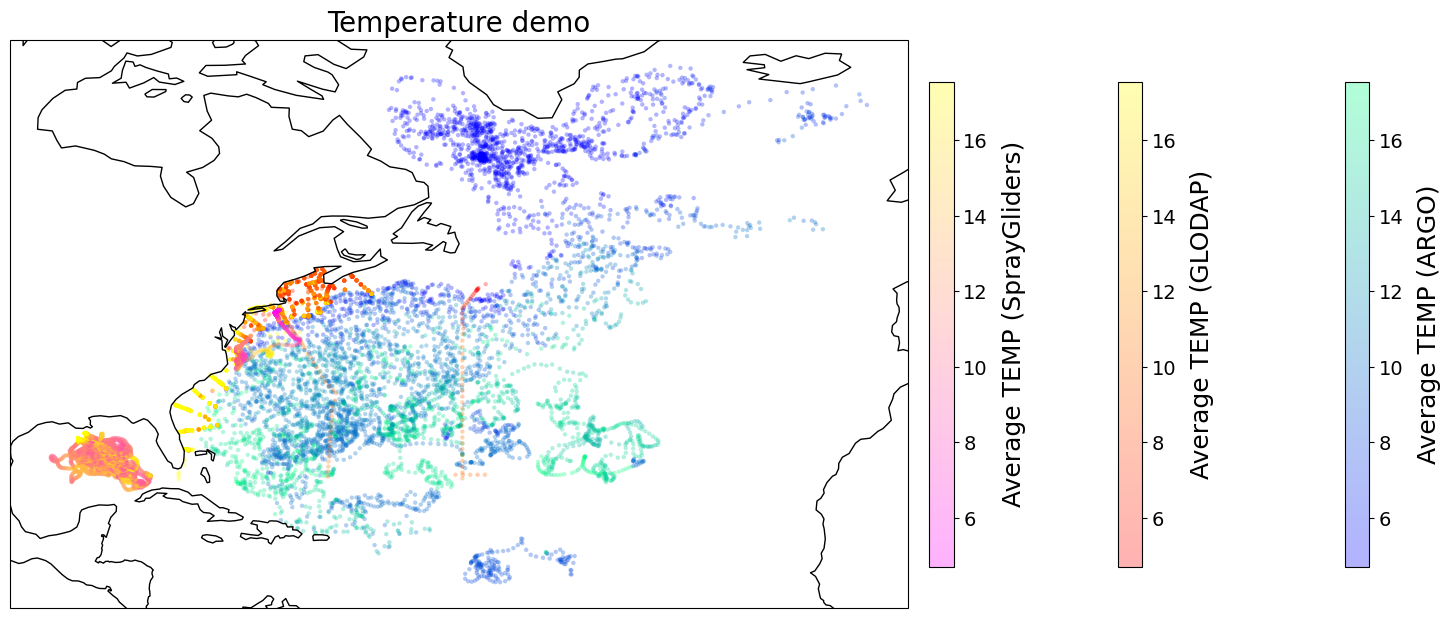

In [9]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from matplotlib import colormaps

refvar = "TEMP"
# Group by 'LATITUDE' and 'LONGITUDE' and database
df_for_map = df.groupby(["LATITUDE", "LONGITUDE", "DB_NAME"]).agg({
    refvar: 'mean'  # Take the mean intensity at that coordinate
}).reset_index()

# Plotting using Cartopy
plt.figure(figsize=(16, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
cbar_min = df_for_map[refvar].quantile(q=0.05)
cbar_max = df_for_map[refvar].quantile(q=0.95)

# Group by DB_NAME and plot each group
df_for_map["DB_NAME"] = pd.Categorical(df_for_map["DB_NAME"], categories=["ARGO","GLODAP","SprayGliders"], ordered=True)

cmaps = iter( ["winter","autumn","spring"] )
for db_name, group in df_for_map.groupby("DB_NAME",observed=False):
    plt.scatter(
        group['LONGITUDE'],
        group['LATITUDE'],
        s=10,
        c=group[refvar],
        vmin=cbar_min,
        vmax=cbar_max,
        cmap=next(cmaps),
        alpha=0.3,
        edgecolors='none',
        transform=ccrs.PlateCarree()
    )
    cbar = plt.colorbar(shrink=0.5, pad=0.02)
    cbar.set_label('Average ' + refvar + " (" + db_name + ")", fontsize=18, labelpad=10)
    cbar.ax.tick_params(labelsize=14)

plt.xlabel('Longitude', fontsize=14)
plt.ylabel('Latitude', fontsize=16)
plt.title('Temperature demo', fontsize=20)
plt.grid(True)
# plt.xlim([lon0, lon1])
# plt.ylim([lat0, lat1])
plt.tight_layout()
plt.show()

### dask approach

dask can be faster at reading parquet databases thanks to its parallel and lazy evaluation of operations. 

When using dask, very few things change compared to using pandas and pyarrow: for example, dask dataframes are almost identical to pandas dataframes and indeed for our needs we will use the same syntax! The only difference is that dask does not evaluate the instructions immediately: it creates so-called delayed objects, through which it builds internally a graph of instructions optimized for the sequence of operations called. To trigger the actual computation we then need to call the `compute()` method of the dask dataframe. This allows dask to handle larger-than-memory datasets, by reading into memory only the portions needed to perform the optimized set of instructions.

We start by importing dask's relevant modules.

In [10]:
import dask
import dask.dataframe as dd

We can use the same filters defined earlier, and we use `read_parquet()` to filter the database and prescribe what we will need.
Note that:
* unlike the pyarrow-pandas approach, here we provide both filters and columns in the same method;
* we provide the schema `crocolake_schema` that we read during the set up of the excercise
* dask uses pyarrow under the hood (`engine` variable, other options are available)

In [11]:
%%time
# Geographical boundaries
lat0 = 25
lat1 = 40
lon0 = -55
lon1 = -40

# Time range
date0 = datetime.datetime(2020, 1, 1, 0, 0, 0)
date1 = datetime.datetime(2025, 1, 1, 0, 0, 0)

# Building filters
refvar = "TEMP"
cols = ["DB_NAME","LATITUDE","LONGITUDE","PRES","JULD",refvar]
filter_coords_time_temp = [
    ("LATITUDE",">",lat0), ("LATITUDE","<",lat1),
    ("LONGITUDE",">",lon0), ("LONGITUDE","<",lon1),
    ("JULD",">",date0), ("JULD","<",date1),
    (refvar,">=",-1e30),(refvar,"<=",+1e30)
]

# Lazily loading data
ddf = dd.read_parquet(
    parquet_dir,
    engine="pyarrow",
    schema=crocolake_schema,
    columns= cols,
    filters=filter_coords_time_temp
)

CPU times: user 9.21 ms, sys: 1.76 ms, total: 11 ms
Wall time: 10.1 ms


It appears dask is much faster! Yet, it actually creates a delayed object, i.e. `ddf` contains the instructions that dask will later use to load the dataframe into memory. This allows us to use `ddf` to schedule all the operations that we'd normally perform on a dataframe. Eventually we will call `ddf.compute()` to actually evaluate the instructions.

If we look at `ddf`, the dataframe will in fact appear empty:

In [12]:
ddf

,DB_NAME,LATITUDE,LONGITUDE,PRES,JULD,TEMP
npartitions=2,,,,,,
,string,double[pyarrow],double[pyarrow],float[pyarrow],timestamp[ns][pyarrow],float[pyarrow]
,...,...,...,...,...,...
,...,...,...,...,...,...


We can explore its first entries with `head()`, which loads into memory only the first 5 entries:

(Note: `head()` can return an empty dataframe even when `ddf` is not empty. This happens because `head()` looks for the first 5 rows of the first partition, which sometimes happens to be empty. If it happens, uncomment the first line: repartitioning the dask dataframe will get rid of empty partitions and solve this.)

In [13]:
#ddf=ddf.repartition(partition_size="300MB")
ddf.head()

,DB_NAME,LATITUDE,LONGITUDE,PRES,JULD,TEMP
0,ARGO,26.46885,-52.33352,0.96,2021-04-01 07:19:30.000778752,23.250999
1,ARGO,26.46885,-52.33352,1.92,2021-04-01 07:19:30.000778752,23.254999
2,ARGO,26.46885,-52.33352,2.96,2021-04-01 07:19:30.000778752,23.266001
3,ARGO,26.46885,-52.33352,4.0,2021-04-01 07:19:30.000778752,23.271
4,ARGO,26.46885,-52.33352,4.92,2021-04-01 07:19:30.000778752,23.277


To load the whole dataframe, we call `compute()` (this returns a pandas dataframe).

In [14]:
%%time
ddf_loaded = ddf.compute()
ddf_loaded

CPU times: user 78.8 ms, sys: 84.9 ms, total: 164 ms
Wall time: 111 ms


,DB_NAME,LATITUDE,LONGITUDE,PRES,JULD,TEMP
0,ARGO,26.46885,-52.33352,0.96,2021-04-01 07:19:30.000778752,23.250999
1,ARGO,26.46885,-52.33352,1.92,2021-04-01 07:19:30.000778752,23.254999
2,ARGO,26.46885,-52.33352,2.96,2021-04-01 07:19:30.000778752,23.266001
3,ARGO,26.46885,-52.33352,4.0,2021-04-01 07:19:30.000778752,23.271
4,ARGO,26.46885,-52.33352,4.92,2021-04-01 07:19:30.000778752,23.277
...,...,...,...,...,...,...
136348,GLODAP,26.472,-52.3337,4167.700195,2021-04-01 03:40:00,2.2019
136349,GLODAP,26.472,-52.3337,4476.399902,2021-04-01 03:40:00,2.1498
136350,GLODAP,26.472,-52.3337,4783.600098,2021-04-01 03:40:00,2.1293
136351,GLODAP,26.472,-52.3337,4989.299805,2021-04-01 03:40:00,2.1425


This took \~30% less time on my machine compared to the previous method! So yes, dask can be much faster than just using pyarrow and pandas. The difference is larger for larger datasets.

If we look into `ddf_loaded` now, it will show the populated pandas dataframe.

(Note: if you compare `ddf_loaded` with `df` loaded with pyarrow, you'll see that the rows are not in the same order, yet under the dataframe you can see that the total number of rows is the same. Also the index seems smaller, but dask holds the dataframe in multiple partitions, and the index is reset at every partition.)

dask's main advantage is not just in loading the data faster, but in performing operations on larger-than-memory data. For example, it can compute the mean value of TEMP *in the whole CrocoLake PHY dataset* without loading the whole data in memory (and pretty quickly, too):

In [15]:
# note that we are not passing any filter conditions or selection of columns to load
ddf_all = dd.read_parquet(
    parquet_dir,
    engine="pyarrow",
    schema=crocolake_schema,
)
refvar_mean = ddf_all[refvar].mean() # refvar_mean is a delayed object: it knows what operations to perform to compute the mean, 
                                   # but doesn't perform them until we call compute() in the next cell

In [16]:
%%time
refvar_mean.compute()

CPU times: user 36.3 ms, sys: 30.1 ms, total: 66.4 ms
Wall time: 50.5 ms


10.320048045852777

(NB: computing the mean on the demo dataset is likely safe with pandas too, but if you were to use the whole CrocoLake, pandas would not be able to load it all in memory, while dask could dynamically load only the necessary data and compute the mean without problems. See [CrocoLake-Python repository](https://github.com/boom-lab/crocolake-python).)

#### Map

When producing the map with our dask approach, we create the `grouped` dataframe from the delayed dataframe `ddf`, and `compute()` it as late as possible.

In this example, the compute that we are triggering includes four operations:
* reading the filtered dataset;
* grouping the dataframe by geographical coordinates;
* averaging by pressure and time;
* resetting the index;

Dask internally builds a graph of all of these operations, so that it knows what subset of data is needed and it optimizes the number and sequence of instructions before executing them.

The two cells below make the same map that we plotted earlier using `pyarrow`.

In [17]:
cols = ["DB_NAME","LATITUDE","LONGITUDE","PRES","JULD","TEMP"]
filter_temp = [
    ("TEMP",">=",-1e30),("TEMP","<=",+1e30)
]

# Lazily loading data
ddf = dd.read_parquet(
    parquet_dir,
    engine="pyarrow",
    schema=crocolake_schema,
    columns= cols,
    filters=filter_temp
)

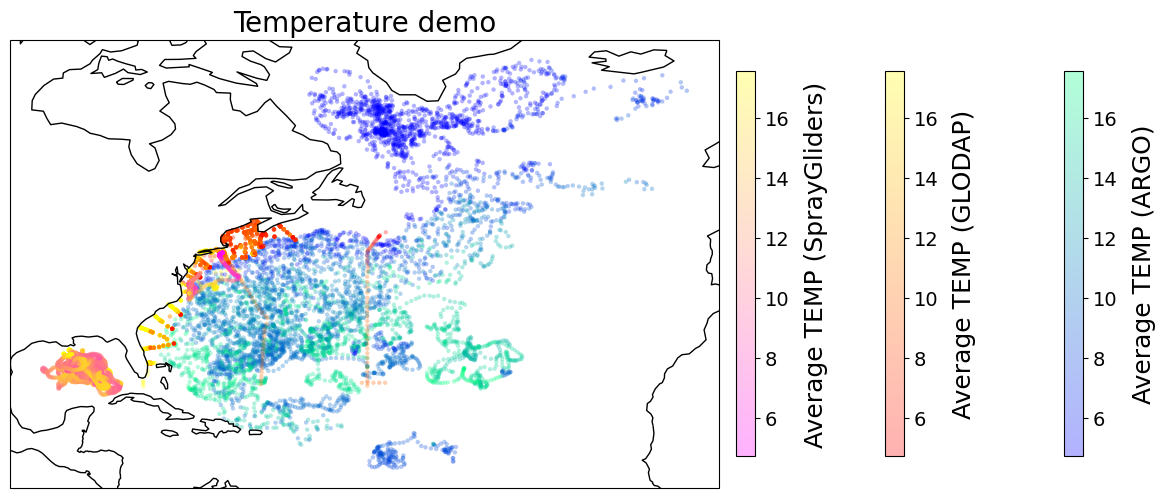

In [18]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from matplotlib import colormaps

# Group by 'LATITUDE' and 'LONGITUDE' and database
ddf_for_map = ddf.groupby(["LATITUDE", "LONGITUDE", "DB_NAME"]).agg({
    refvar: 'mean'  # Take the mean intensity at that coordinate
}).reset_index()

# Plotting using Cartopy
plt.figure(figsize=(16, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
cbar_min = ddf_for_map[refvar].quantile(q=0.05).compute()
cbar_max = ddf_for_map[refvar].quantile(q=0.95).compute()

# Group by DB_NAME and plot each group
ddf['DB_NAME'] = ddf.DB_NAME.astype('category')

cmaps = iter( ["winter","autumn","spring"] )
for db_name, group in ddf_for_map.compute().groupby("DB_NAME"):
    plt.scatter(
        group['LONGITUDE'],
        group['LATITUDE'],
        s=10,
        c=group[refvar],
        vmin=cbar_min,
        vmax=cbar_max,
        cmap=next(cmaps),
        alpha=0.3,
        edgecolors='none',
        transform=ccrs.PlateCarree()
    )
    cbar = plt.colorbar(shrink=0.5, pad=0.02)
    cbar.set_label('Average ' + refvar + " (" + db_name + ")", fontsize=18, labelpad=10)
    cbar.ax.tick_params(labelsize=14)
    
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Temperature demo', fontsize=20)
plt.grid(True)
plt.show()

### Suggested exercises

Try and access some other data, for example:
* filtering by different time periods;
* mapping a different parameter;
* restraining the data of interest further by imposing the pressure PRES to be below 100db;
* performing reads/manipulations that you would need to perform your tasks.

If you encounter any issues, please [reach out](enrico.milanese@whoi.edu)!

#### 